In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pynwb import NWBHDF5IO

def data_choice(path):
    with NWBHDF5IO(path, 'r') as io:
        nwb = io.read()
        units_df = nwb.units.to_dataframe()
        trials_df = nwb.trials.to_dataframe()
    return units_df, trials_df

# different path: 
path1 = 'data/myriam/MH029_20250504_113751.nwb'
path2 = 'data/myriam/MH031_20250509_102210.nwb'


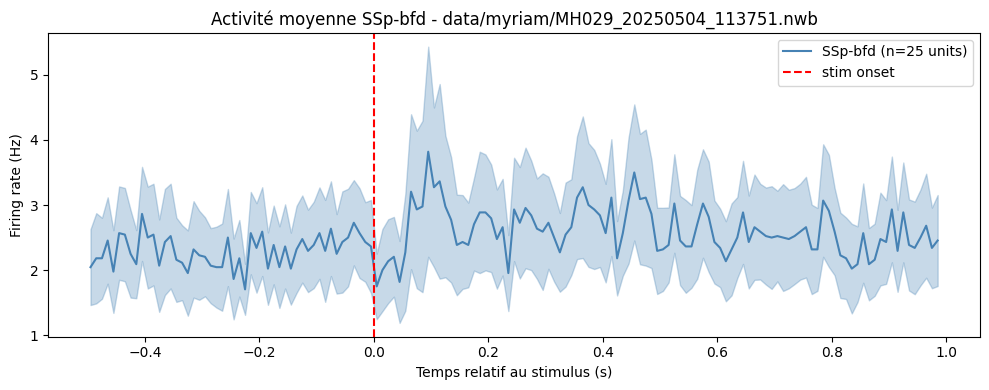

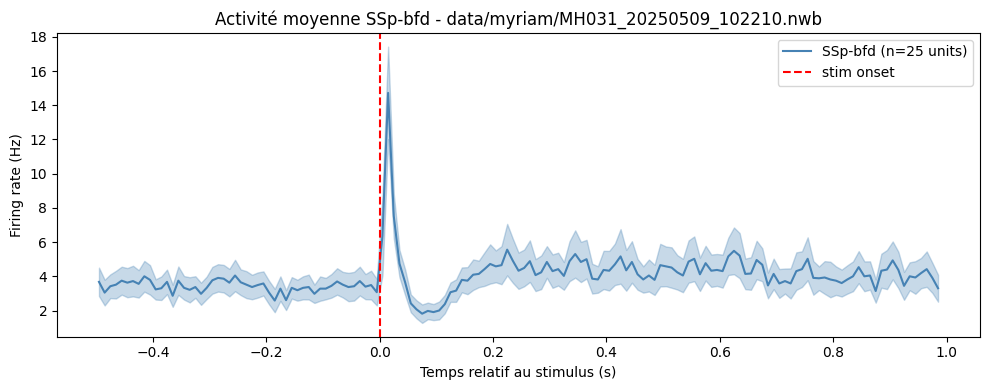

In [2]:
def plot_and_save_psth(path):
    units_df, trials_df = data_choice(path)

    # Filtrer SSp-bfd
    ssp = units_df[units_df['ccf_parent_acronym'] == 'SSp-bfd']
    whisker_stim = trials_df[trials_df['whisker_stim'] == 1]
    auditory_stim = trials_df[trials_df['auditory_stim'] == 1]

    # Paramètres PSTH
    pre, post = 0.5, 1.0   # secondes avant/après le stimulus
    bin_size = 0.01         # 10ms bins
    bins = np.arange(-pre, post, bin_size)

    # Aligner sur stim_onset de chaque trial
    stim_times = whisker_stim['stim_onset'].values

    psth_all = []
    for _, unit in ssp.iterrows():
        spike_times = unit['spike_times']
        counts = np.zeros(len(bins) - 1)
        for t in stim_times:
            aligned = spike_times - t
            counts += np.histogram(aligned, bins=bins)[0]
        # Convertir en Hz
        psth_all.append(counts / (len(stim_times) * bin_size))

    psth_mean = np.mean(psth_all, axis=0)
    psth_sem = np.std(psth_all, axis=0) / np.sqrt(len(psth_all))

    # Plot
    t = bins[:-1] + bin_size / 2
    plt.figure(figsize=(10, 4))
    plt.plot(t, psth_mean, color='steelblue', label=f'SSp-bfd (n={len(ssp)} units)')
    plt.fill_between(t, psth_mean - psth_sem, psth_mean + psth_sem, alpha=0.3, color='steelblue')
    plt.axvline(0, color='red', linestyle='--', label='stim onset')
    plt.xlabel('Temps relatif au stimulus (s)')
    plt.ylabel('Firing rate (Hz)')
    plt.title(f'Activité moyenne SSp-bfd - {path}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return psth_mean, psth_sem

# Générer les PSTH pour les deux sessions
psth1_mean, psth1_sem = plot_and_save_psth(path1)
psth2_mean, psth2_sem = plot_and_save_psth(path2)

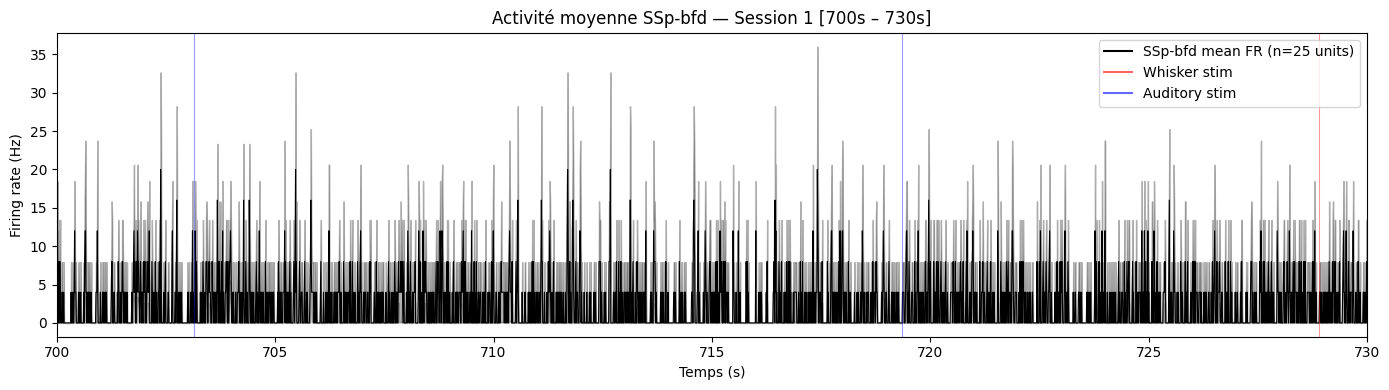

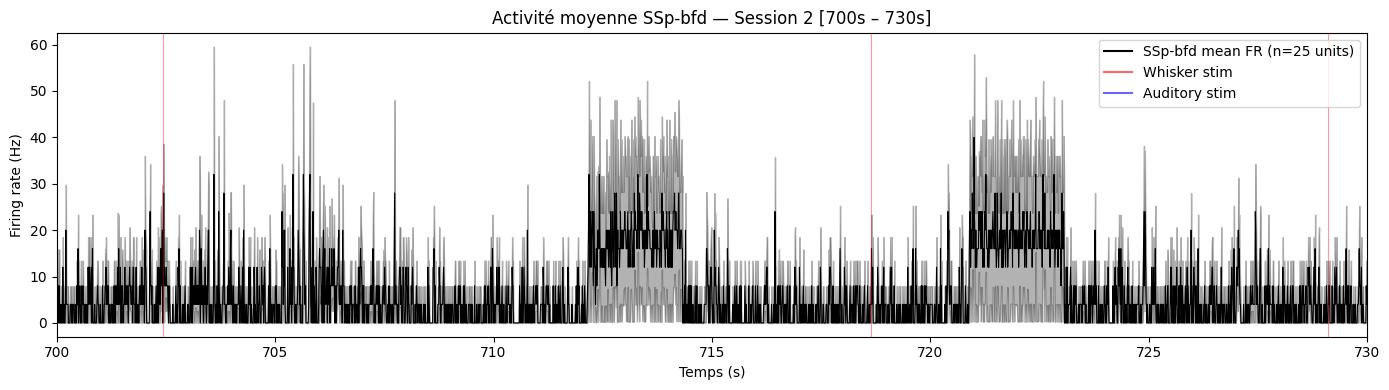

In [3]:
def plot_psth_with_stim_onsets(session=1, t_start=25, t_end=30, bin_size=0.1):
    units_df, trials_df = data_choice(path1 if session == 1 else path2)
    ssp = units_df[units_df['ccf_parent_acronym'] == 'SSp-bfd']

    bins = np.arange(t_start, t_end + bin_size, bin_size)
    t = bins[:-1] + bin_size / 2

    # Firing rate moyenne sur tous les neurones SSp-bfd
    fr_all = []
    for _, unit in ssp.iterrows():
        spike_times = unit['spike_times']
        spikes_in_window = spike_times[(spike_times >= t_start) & (spike_times < t_end)]
        counts, _ = np.histogram(spikes_in_window, bins=bins)
        fr_all.append(counts / bin_size)

    fr_mean = np.mean(fr_all, axis=0)
    fr_sem  = np.std(fr_all, axis=0) / np.sqrt(len(fr_all))

    # Stim onsets dans la fenêtre
    wh_times  = trials_df.loc[(trials_df['whisker_stim'] == 1) &
                            (trials_df['stim_onset'] >= t_start) &
                            (trials_df['stim_onset'] < t_end), 'stim_onset'].values
    aud_times = trials_df.loc[(trials_df['auditory_stim'] == 1) &
                            (trials_df['stim_onset'] >= t_start) &
                            (trials_df['stim_onset'] < t_end), 'stim_onset'].values

    # Plot
    from matplotlib.lines import Line2D

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(t, fr_mean, color='k', lw=0.8)
    ax.fill_between(t, fr_mean - fr_sem, fr_mean + fr_sem, alpha=0.3, color='k')

    for wt in wh_times:
        ax.axvline(wt, color='red',  alpha=0.4, lw=0.8)
    for at in aud_times:
        ax.axvline(at, color='blue', alpha=0.4, lw=0.8)

    legend_handles = [
        Line2D([0], [0], color='k',    label=f'SSp-bfd mean FR (n={len(ssp)} units)'),
        Line2D([0], [0], color='red',  alpha=0.6, label='Whisker stim'),
        Line2D([0], [0], color='blue', alpha=0.6, label='Auditory stim'),
    ]
    ax.legend(handles=legend_handles, loc='upper right')
    ax.set_xlabel('Temps (s)')
    ax.set_ylabel('Firing rate (Hz)')
    ax.set_title(f'Activité moyenne SSp-bfd — Session {session} [{t_start}s – {t_end}s]')
    ax.set_xlim(t_start, t_end)
    plt.tight_layout()
    plt.show()

t_start = 700
t_end = t_start + 30
for session in range(2):
    plot_psth_with_stim_onsets(session=session+1, t_start=t_start, t_end=t_end, bin_size=0.01)

# a partir d'ici: session 2 meme pipeline de différenciation que tentatives.ipynb (coding direction et plot vs false positive, auditory trials pas dans FP)

In [4]:
# ── Session 2 : construction AP_Bin_Matrix (SSp-bfd uniquement) ──────────────
from scipy.ndimage import gaussian_filter1d

units_df2, trials_df2 = data_choice(path2)

# Filtrer SSp-bfd et exclure les trials auditory
ssp2      = units_df2[units_df2['ccf_parent_acronym'] == 'SSp-bfd']
tr2       = trials_df2[trials_df2['auditory_stim'] == 0].copy().reset_index(drop=True)

spike_times2 = [unit['spike_times'] for _, unit in ssp2.iterrows()]
print(f"SSp-bfd units session 2 : {len(spike_times2)}")
print(f"Trials (sans auditory)  : {len(tr2)}")

Bin_size2          = 0.01
AP_Bin_Resolution2 = 1.0 / Bin_size2
duration2          = float(trials_df2['stop_time'].max())
n_bins2            = int(np.round(duration2 * AP_Bin_Resolution2))
edges2             = np.linspace(0.0, n_bins2 * Bin_size2, n_bins2 + 1)

AP_Bin_Matrx2 = np.zeros((len(spike_times2), n_bins2), dtype=np.float32)
for n, st in enumerate(spike_times2):
    counts, _ = np.histogram(st, bins=edges2)
    AP_Bin_Matrx2[n, :] = counts

print(f"AP_Bin_Matrx2 shape : {AP_Bin_Matrx2.shape}")

SSp-bfd units session 2 : 25
Trials (sans auditory)  : 242
AP_Bin_Matrx2 shape : (25, 303661)


Whisker stim trials : 172
Catch trials        : 70


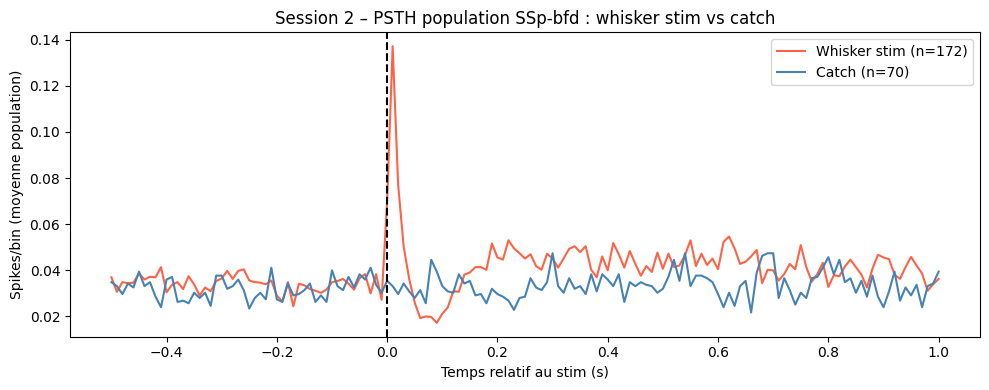

In [5]:
# ── Matrices event-triggered : whisker stim vs catch ──────────────────────────
def event_triggered_mean(AP_Bin_Matrx, event_times, AP_Bin_Resolution, pre_bins=50, post_bins=100):
    W = pre_bins + post_bins + 1
    M = np.zeros((AP_Bin_Matrx.shape[0], W), dtype=np.float32)
    n = 0
    for ev in event_times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        pt1, pt2 = pt - pre_bins, pt + post_bins
        if pt1 < 0 or pt2 >= AP_Bin_Matrx.shape[1]:
            continue
        M += AP_Bin_Matrx[:, pt1:pt2+1]
        n += 1
    return M / max(n, 1), n

def event_triggered_matrix(AP_Bin_Matrx, event_times, AP_Bin_Resolution, pre_bins=50, post_bins=100):
    W = pre_bins + post_bins + 1
    mats = []
    for ev in event_times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        pt1, pt2 = pt - pre_bins, pt + post_bins
        if pt1 < 0 or pt2 >= AP_Bin_Matrx.shape[1]:
            continue
        mats.append(AP_Bin_Matrx[:, pt1:pt2+1].astype(np.float32))
    if len(mats) == 0:
        return None, 0
    return np.stack(mats, axis=0), len(mats)

# Stim times (whisker uniquement)
stim_sel2    = tr2['whisker_stim'].astype(bool) & tr2['whisker_stim_time'].notna()
Stim_times2  = np.sort(tr2.loc[stim_sel2, 'whisker_stim_time'].to_numpy())

# Catch times
catch_sel2   = tr2['no_stim'].astype(bool) & tr2['no_stim_time'].notna()
Catch_times2 = np.sort(tr2.loc[catch_sel2, 'no_stim_time'].to_numpy())

print(f"Whisker stim trials : {len(Stim_times2)}")
print(f"Catch trials        : {len(Catch_times2)}")

pre_bins2, post_bins2 = 50, 100
time_axis2 = (np.arange(pre_bins2 + post_bins2 + 1) - pre_bins2) * Bin_size2

STM_MTRX2,   n_stim2  = event_triggered_mean(AP_Bin_Matrx2, Stim_times2,  AP_Bin_Resolution2, pre_bins2, post_bins2)
CATCH_MTRX2, n_catch2 = event_triggered_mean(AP_Bin_Matrx2, Catch_times2, AP_Bin_Resolution2, pre_bins2, post_bins2)

plt.figure(figsize=(10, 4))
plt.plot(time_axis2, STM_MTRX2.mean(axis=0),   color='tomato',    label=f'Whisker stim (n={n_stim2})')
plt.plot(time_axis2, CATCH_MTRX2.mean(axis=0), color='steelblue', label=f'Catch (n={n_catch2})')
plt.axvline(0, linestyle='--', color='k')
plt.xlabel('Temps relatif au stim (s)')
plt.ylabel('Spikes/bin (moyenne population)')
plt.title('Session 2 – PSTH population SSp-bfd : whisker stim vs catch')
plt.legend()
plt.tight_layout()
plt.show()

CD2 norm: 1.0000  shape: (25,)


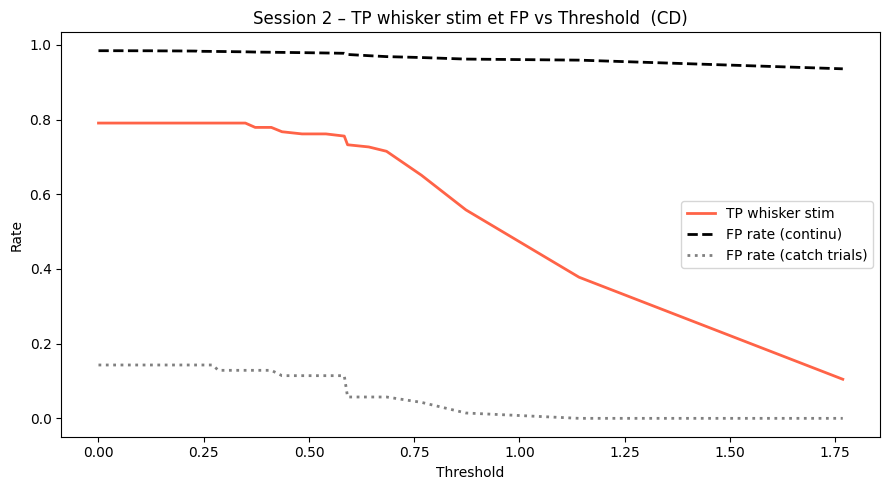

In [6]:
# ── Coding Direction + TP/FP vs Threshold ─────────────────────────────────────
Pop_Vect_Stim2  = STM_MTRX2[:, 50:55].mean(axis=1)
Pop_Vect_Catch2 = CATCH_MTRX2[:, 50:55].mean(axis=1)

CD2 = Pop_Vect_Stim2 - Pop_Vect_Catch2
CD2 = CD2 / (np.linalg.norm(CD2) + 1e-12)
print(f"CD2 norm: {np.linalg.norm(CD2):.4f}  shape: {CD2.shape}")

# Projection sur signal continu
score2 = CD2 @ AP_Bin_Matrx2
t_sig2 = np.arange(len(score2)) * Bin_size2

t_start2      = float(trials_df2['start_time'].min())
t_end2        = float(trials_df2['stop_time'].max())
tol_post2     = 0.05
refractory_s2 = 0.2

def detect_peaks2(score, t, thr, refractory_s, Bin_size, t_start, t_end):
    mask = (t >= t_start) & (t <= t_end) & (score > thr)
    idx  = np.where(mask)[0]
    if idx.size == 0:
        return np.array([], dtype=float)
    cuts   = np.where(np.diff(idx) > 1)[0] + 1
    groups = np.split(idx, cuts)
    peaks  = np.array([g[np.argmax(score[g])] for g in groups], dtype=int)
    min_b  = int(np.round(refractory_s / Bin_size))
    keep   = [peaks[0]]
    for p in peaks[1:]:
        if p - keep[-1] >= min_b:
            keep.append(p)
        elif score[p] > score[keep[-1]]:
            keep[-1] = p
    return t[np.array(keep, dtype=int)]

in_range2 = (t_sig2 >= t_start2) & (t_sig2 <= t_end2)
ths2      = np.percentile(score2[in_range2], np.linspace(50, 99.9, 80))

tp_curve2      = []
fp_cont_curve2 = []
fp_catch_curve2 = []

for thr in ths2:
    det_t = detect_peaks2(score2, t_sig2, thr, refractory_s2, Bin_size2, t_start2, t_end2)
    n_det = max(len(det_t), 1)

    # FP continu : détections hors fenêtre stim
    in_win_stim = np.zeros(len(det_t), dtype=bool)
    for st in Stim_times2:
        in_win_stim |= (det_t >= st) & (det_t <= st + tol_post2)
    fp_cont_curve2.append(np.sum(~in_win_stim) / n_det)

    # FP catch
    hits_catch = sum(
        np.any((det_t >= st) & (det_t <= st + tol_post2))
        for st in Catch_times2
    )
    fp_catch_curve2.append(hits_catch / max(len(Catch_times2), 1))

    # TP whisker stim
    hits = sum(
        np.any((det_t >= st) & (det_t <= st + tol_post2))
        for st in Stim_times2
    )
    tp_curve2.append(hits / max(len(Stim_times2), 1))

tp_curve2       = np.array(tp_curve2)
fp_cont_curve2  = np.array(fp_cont_curve2)
fp_catch_curve2 = np.array(fp_catch_curve2)

plt.figure(figsize=(9, 5))
plt.plot(ths2, tp_curve2,       color='tomato', lw=2,               label='TP whisker stim')
plt.plot(ths2, fp_cont_curve2,  color='black',  lw=2, linestyle='--', label='FP rate (continu)')
plt.plot(ths2, fp_catch_curve2, color='gray',   lw=2, linestyle=':',  label='FP rate (catch trials)')
plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.title('Session 2 – TP whisker stim et FP vs Threshold  (CD)')
plt.legend()
plt.tight_layout()
plt.show()

Threshold médian : 0.094  |  TP : 136  |  FP : 8522
Cosine sim TP : 0.608 ± 0.127
Cosine sim FP : 0.506 ± 0.155


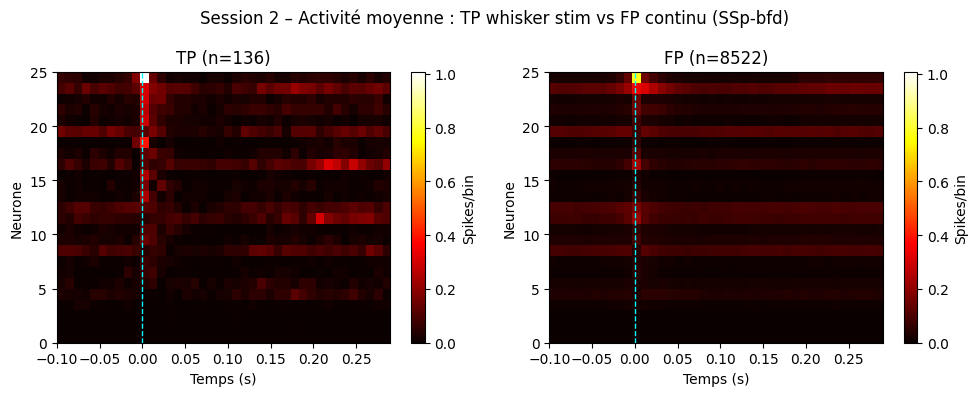

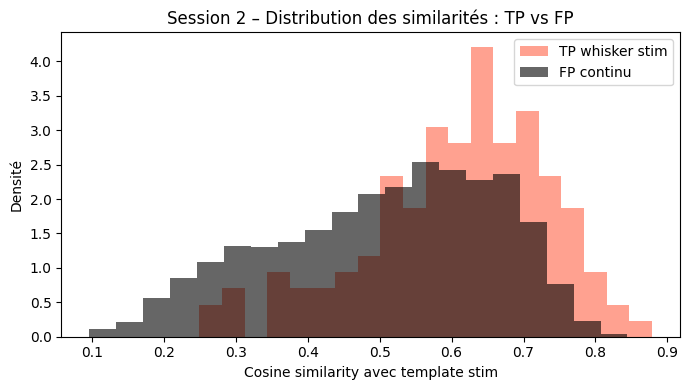

In [7]:
# ── Similarité FP vs TP : heatmaps + cosine similarity ────────────────────────
template2    = Pop_Vect_Stim2 / (np.linalg.norm(Pop_Vect_Stim2) + 1e-12)
thr_fixed2   = np.median(ths2)
det_t2       = detect_peaks2(score2, t_sig2, thr_fixed2, refractory_s2, Bin_size2, t_start2, t_end2)

# Séparer TP / FP
in_win_stim2 = np.zeros(len(det_t2), dtype=bool)
for st in Stim_times2:
    in_win_stim2 |= (det_t2 >= st) & (det_t2 <= st + tol_post2)

tp_times2 = det_t2[in_win_stim2]
fp_times2 = det_t2[~in_win_stim2]
print(f"Threshold médian : {thr_fixed2:.3f}  |  TP : {len(tp_times2)}  |  FP : {len(fp_times2)}")

# Extraction fenêtres
pre_w, post_w = 10, 30
t_win2 = (np.arange(pre_w + post_w) - pre_w) * Bin_size2

def extract_windows(times, AP_Bin_Matrx, AP_Bin_Resolution, pre, post):
    segs = []
    for ev in times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        if pt - pre < 0 or pt + post > AP_Bin_Matrx.shape[1]:
            continue
        segs.append(AP_Bin_Matrx[:, pt - pre:pt + post])
    return np.array(segs) if segs else None

def pop_vecs_at_peak(segs, pre, W=5):
    vecs = segs[:, :, pre:pre + W].mean(axis=2)
    return vecs / (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-12)

segs_tp2 = extract_windows(tp_times2, AP_Bin_Matrx2, AP_Bin_Resolution2, pre_w, post_w)
segs_fp2 = extract_windows(fp_times2, AP_Bin_Matrx2, AP_Bin_Resolution2, pre_w, post_w)

cos_tp2 = pop_vecs_at_peak(segs_tp2, pre_w) @ template2
cos_fp2 = pop_vecs_at_peak(segs_fp2, pre_w) @ template2
print(f"Cosine sim TP : {cos_tp2.mean():.3f} ± {cos_tp2.std():.3f}")
print(f"Cosine sim FP : {cos_fp2.mean():.3f} ± {cos_fp2.std():.3f}")

# Heatmaps TP vs FP
sort_idx2 = np.argsort(segs_tp2.mean(axis=0)[:, pre_w:pre_w+5].mean(axis=1))[::-1]
lim2 = max(segs_tp2.mean(axis=0).max(), segs_fp2.mean(axis=0).max())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, segs, label in zip(axes, [segs_tp2, segs_fp2], [f'TP (n={len(tp_times2)})', f'FP (n={len(fp_times2)})']):
    data = segs.mean(axis=0)[sort_idx2]
    im = ax.imshow(data, aspect='auto', cmap='hot', vmin=0, vmax=lim2,
                   extent=[t_win2[0], t_win2[-1], 0, data.shape[0]])
    ax.axvline(0, color='cyan', lw=1, linestyle='--')
    ax.set_title(label)
    ax.set_xlabel('Temps (s)')
    ax.set_ylabel('Neurone')
    plt.colorbar(im, ax=ax, label='Spikes/bin')
plt.suptitle('Session 2 – Activité moyenne : TP whisker stim vs FP continu (SSp-bfd)')
plt.tight_layout()
plt.show()

# Distribution cosine similarities
plt.figure(figsize=(7, 4))
plt.hist(cos_tp2, bins=20, alpha=0.6, color='tomato', label='TP whisker stim', density=True)
plt.hist(cos_fp2, bins=20, alpha=0.6, color='black',  label='FP continu',      density=True)
plt.xlabel('Cosine similarity avec template stim')
plt.ylabel('Densité')
plt.title('Session 2 – Distribution des similarités : TP vs FP')
plt.legend()
plt.tight_layout()
plt.show()

Lick times : 1013
Meilleur threshold : 0.3488  |  TP=0.79  FP=0.98
Détections totales : 7340


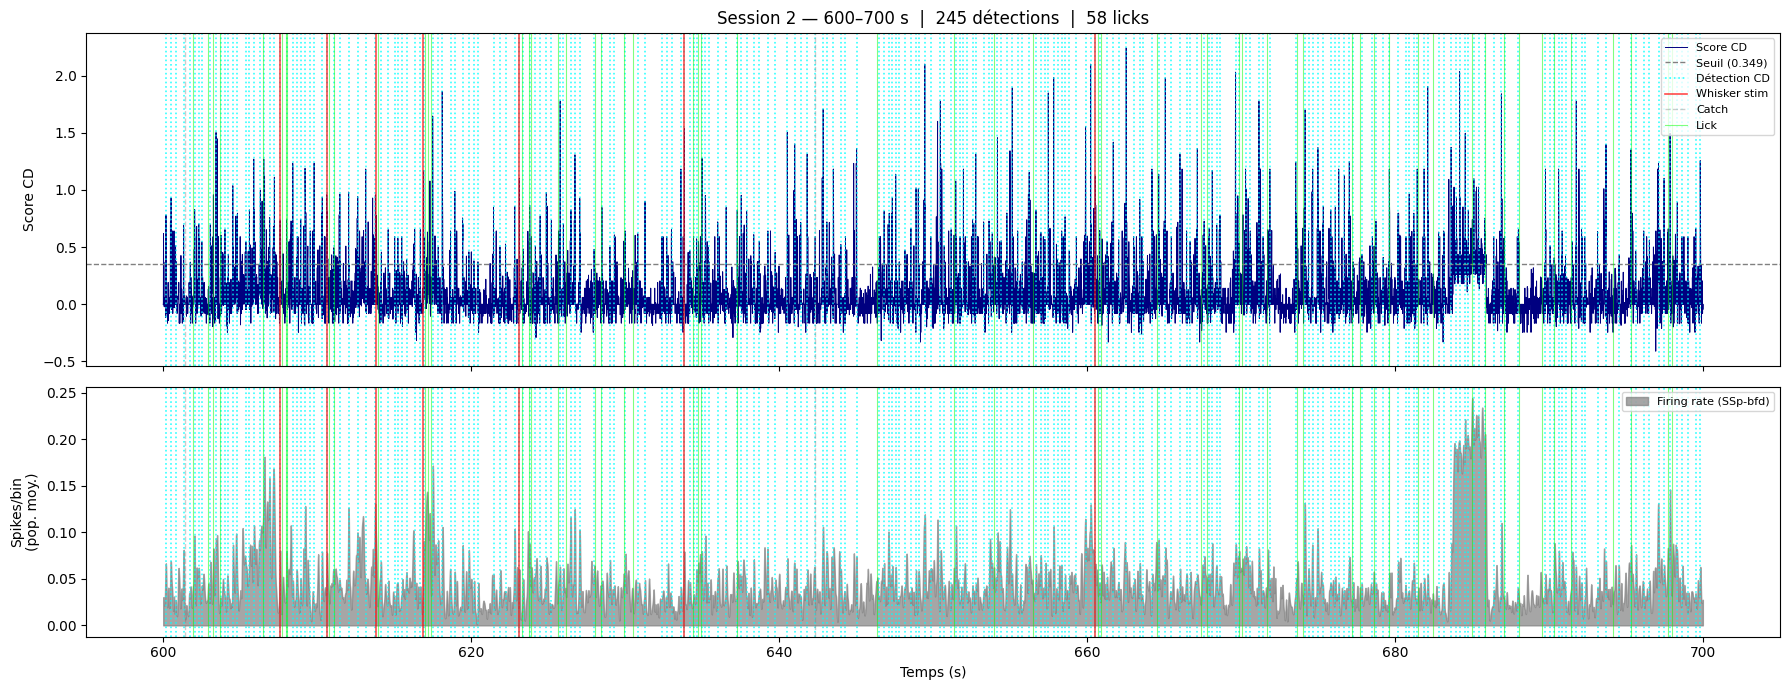

In [8]:
# ── Chargement lick times + visualisation ─────────────────────────────────────
from scipy.ndimage import gaussian_filter1d

with NWBHDF5IO(path2, 'r') as io:
    nwb2_beh = io.read()
    all_lick_times_piezo2 = np.array(
        nwb2_beh.processing['behavior']['BehavioralEvents']['piezo_lick_times'].timestamps[:]
    )

print(f"Lick times : {len(all_lick_times_piezo2)}")

# Meilleur threshold CD : max(TP - FP_continu)
best_i2   = np.argmax(tp_curve2 - fp_cont_curve2)
best_thr2 = ths2[best_i2]
print(f"Meilleur threshold : {best_thr2:.4f}  |  TP={tp_curve2[best_i2]:.2f}  FP={fp_cont_curve2[best_i2]:.2f}")

det_t_best2 = detect_peaks2(score2, t_sig2, best_thr2, refractory_s2, Bin_size2, t_start2, t_end2)
print(f"Détections totales : {len(det_t_best2)}")

# Auditory stim times (depuis trials_df2 non filtré)
aud_stim_win_times2 = np.sort(trials_df2.loc[
    trials_df2['auditory_stim'].astype(bool) & trials_df2['auditory_stim_time'].notna(),
    'auditory_stim_time'
].to_numpy())

# Visualisation sur une fenêtre
t0_vis2, t1_vis2 = 600.0, 700.0

mask_score_v  = (t_sig2 >= t0_vis2) & (t_sig2 <= t1_vis2)
det_win2      = det_t_best2[(det_t_best2 >= t0_vis2) & (det_t_best2 <= t1_vis2)]
lick_win2     = all_lick_times_piezo2[(all_lick_times_piezo2 >= t0_vis2) & (all_lick_times_piezo2 <= t1_vis2)]
wh_win2       = Stim_times2[(Stim_times2 >= t0_vis2) & (Stim_times2 <= t1_vis2)]
aud_win2      = aud_stim_win_times2[(aud_stim_win_times2 >= t0_vis2) & (aud_stim_win_times2 <= t1_vis2)]
catch_win2    = Catch_times2[(Catch_times2 >= t0_vis2) & (Catch_times2 <= t1_vis2)]

b0v2, b1v2 = int(t0_vis2 * AP_Bin_Resolution2), int(t1_vis2 * AP_Bin_Resolution2)
t_rate_v2  = np.arange(b0v2, b1v2) * Bin_size2
rate_sm_v2 = gaussian_filter1d(AP_Bin_Matrx2[:, b0v2:b1v2].mean(axis=0), sigma=3)

fig, axes = plt.subplots(2, 1, figsize=(18, 7), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1.5]})

# Score CD + détections
ax = axes[0]
ax.plot(t_sig2[mask_score_v], score2[mask_score_v], color='navy', lw=0.7, label='Score CD')
ax.axhline(best_thr2, color='gray', lw=1.0, linestyle='--', label=f'Seuil ({best_thr2:.3f})')
for dt in det_win2:
    ax.axvline(dt, color='cyan',      alpha=0.8, lw=1.2, linestyle=':', label='Détection CD')
for st in wh_win2:
    ax.axvline(st, color='red',       alpha=0.7, lw=1.2,               label='Whisker stim')
for at in aud_win2:
    ax.axvline(at, color='blue',      alpha=0.7, lw=1.2,               label='Auditory stim')
for ct in catch_win2:
    ax.axvline(ct, color='gray',      alpha=0.4, lw=1.0, linestyle='--', label='Catch')
for lt in lick_win2:
    ax.axvline(lt, color='lime',      alpha=0.5, lw=0.8,               label='Lick')
handles, labels_l = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels_l, handles)).values(), dict(zip(labels_l, handles)).keys(), fontsize=8, loc='upper right')
ax.set_ylabel('Score CD')
ax.set_title(f'Session 2 — {t0_vis2:.0f}–{t1_vis2:.0f} s  |  {len(det_win2)} détections  |  {len(lick_win2)} licks')

# Firing rate
ax2 = axes[1]
ax2.fill_between(t_rate_v2, rate_sm_v2, alpha=0.7, color='gray', label='Firing rate (SSp-bfd)')
for dt in det_win2:
    ax2.axvline(dt, color='cyan',  alpha=0.8, lw=1.2, linestyle=':')
for st in wh_win2:
    ax2.axvline(st, color='red',   alpha=0.7, lw=1.2)
for at in aud_win2:
    ax2.axvline(at, color='blue',  alpha=0.7, lw=1.2)
for ct in catch_win2:
    ax2.axvline(ct, color='gray',  alpha=0.4, lw=1.0, linestyle='--')
for lt in lick_win2:
    ax2.axvline(lt, color='lime',  alpha=0.5, lw=0.8)
ax2.set_ylabel('Spikes/bin\n(pop. moy.)')
ax2.set_xlabel('Temps (s)')
ax2.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

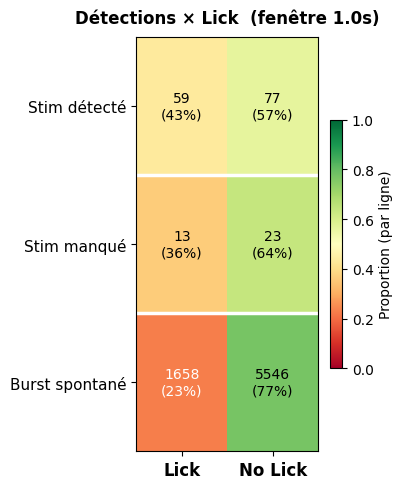

In [9]:
# ── Matrice : (stim détecté / stim manqué / burst) × (lick / no lick) ─────────
lick_window_s2 = 1.0  # fenêtre 1s après détection pour compter un lick

tp_lick2, tp_nolick2, miss_lick2, miss_nolick2 = 0, 0, 0, 0
for st in Stim_times2:
    detected = np.any((det_t_best2 >= st) & (det_t_best2 <= st + tol_post2))
    lick     = np.any((all_lick_times_piezo2 >= st) & (all_lick_times_piezo2 <= st + lick_window_s2))
    if   detected and lick:     tp_lick2    += 1
    elif detected and not lick: tp_nolick2  += 1
    elif not detected and lick: miss_lick2  += 1
    else:                       miss_nolick2 += 1

# Bursts : détections hors fenêtre stim
burst_lick2, burst_nolick2 = 0, 0
for dt in det_t_best2:
    if not np.any((dt >= Stim_times2) & (dt <= Stim_times2 + tol_post2)):
        if np.any((all_lick_times_piezo2 >= dt) & (all_lick_times_piezo2 <= dt + lick_window_s2)):
            burst_lick2 += 1
        else:
            burst_nolick2 += 1

row_labels2 = ['Stim détecté', 'Stim manqué', 'Burst spontané']
matrix2 = np.array([
    [tp_lick2,    tp_nolick2],
    [miss_lick2,  miss_nolick2],
    [burst_lick2, burst_nolick2],
], dtype=float)

row_sums2 = matrix2.sum(axis=1, keepdims=True)
mat_norm2 = np.where(row_sums2 > 0, matrix2 / row_sums2, 0.0)

fig, ax = plt.subplots(figsize=(4, 5))
im = ax.imshow(mat_norm2, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Lick', 'No Lick'], fontsize=12, fontweight='bold')
ax.set_yticks(range(len(row_labels2)))
ax.set_yticklabels(row_labels2, fontsize=11)
ax.axhline(0.5, color='white', linewidth=2.5)
ax.axhline(1.5, color='white', linewidth=2.5)
for i in range(len(row_labels2)):
    for j in range(2):
        n = int(matrix2[i, j])
        p = mat_norm2[i, j]
        txt = f"{n}\n({p:.0%})" if row_sums2[i, 0] > 0 else '—'
        color = 'white' if p <= 0.25 else 'black'
        ax.text(j, i, txt, ha='center', va='center', fontsize=10, color=color)
ax.set_title(f'Détections × Lick  (fenêtre {lick_window_s2:.1f}s)', fontsize=12, fontweight='bold', pad=10)
plt.colorbar(im, ax=ax, label='Proportion (par ligne)', shrink=0.6)
plt.tight_layout()
plt.show()

Bursts hors trials → lick: 1489  |  no lick: 4871


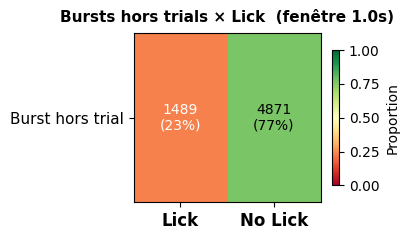

In [10]:
# ── Matrice bursts HORS trials (whisker + auditory + catch) × (lick / no lick) ─
# Un burst est "dans un trial" s'il tombe dans [trial_onset, trial_onset + lick_window_s2]
# pour n'importe quel type de trial

# Récupérer tous les onsets (whisker + auditory + catch)
aud_times2   = np.sort(trials_df2.loc[
    trials_df2['auditory_stim'].astype(bool) & trials_df2['auditory_stim_time'].notna(),
    'auditory_stim_time'
].to_numpy())
all_trial_onsets2 = np.sort(np.concatenate([Stim_times2, aud_times2, Catch_times2]))

def near_any_trial(t):
    return np.any((t >= all_trial_onsets2) & (t <= all_trial_onsets2 + lick_window_s2))

# Garder seulement les bursts hors trials
burst_out_lick,   burst_out_nolick   = 0, 0
for dt in det_t_best2:
    if not np.any((dt >= Stim_times2) & (dt <= Stim_times2 + tol_post2)):  # c'est un burst
        if not near_any_trial(dt):                                           # hors de tout trial
            if np.any((all_lick_times_piezo2 >= dt) & (all_lick_times_piezo2 <= dt + lick_window_s2)):
                burst_out_lick += 1
            else:
                burst_out_nolick += 1

print(f"Bursts hors trials → lick: {burst_out_lick}  |  no lick: {burst_out_nolick}")

row_labels_out = ['Burst hors trial']
matrix_out = np.array([[burst_out_lick, burst_out_nolick]], dtype=float)
row_sums_out  = matrix_out.sum(axis=1, keepdims=True)
mat_norm_out  = np.where(row_sums_out > 0, matrix_out / row_sums_out, 0.0)

fig, ax = plt.subplots(figsize=(4, 2.5))
im = ax.imshow(mat_norm_out, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Lick', 'No Lick'], fontsize=12, fontweight='bold')
ax.set_yticks([0])
ax.set_yticklabels(row_labels_out, fontsize=11)
for j in range(2):
    n = int(matrix_out[0, j])
    p = mat_norm_out[0, j]
    txt = f"{n}\n({p:.0%})" if row_sums_out[0, 0] > 0 else '—'
    color = 'white' if p <= 0.25 else 'black'
    ax.text(j, 0, txt, ha='center', va='center', fontsize=10, color=color)
ax.set_title(f'Bursts hors trials × Lick  (fenêtre {lick_window_s2:.1f}s)', fontsize=11, fontweight='bold', pad=8)
plt.colorbar(im, ax=ax, label='Proportion', shrink=0.8)
plt.tight_layout()
plt.show()

{'stim': 57, 'burst': 1183, 'none': 7}


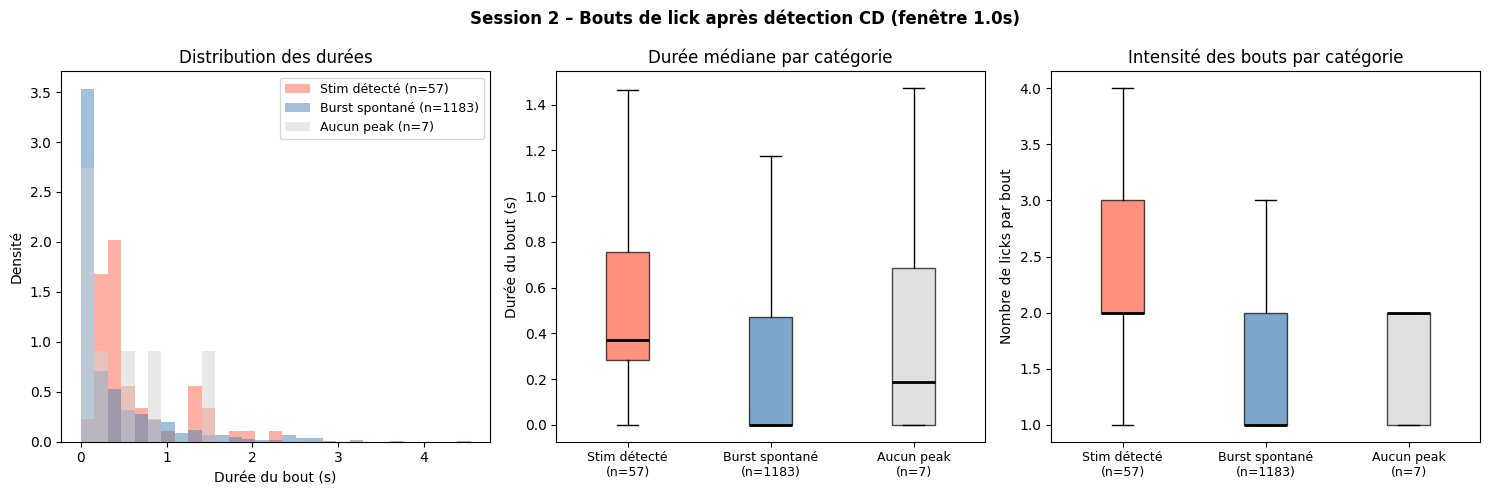

In [11]:
# ── Analyse des bouts de lick : durée par catégorie ───────────────────────────
# Regrouper les licks en bouts (inter-lick > 1s = nouveau bout)
lick_ts2     = np.sort(all_lick_times_piezo2)
gaps2        = np.diff(lick_ts2)
cuts2        = np.where(gaps2 > 1.0)[0] + 1
bout_groups2 = np.split(lick_ts2, cuts2)
bout_starts2 = np.array([g[0]  for g in bout_groups2])
bout_ends2   = np.array([g[-1] for g in bout_groups2])

def bout_dur2(t_ref):
    """Retourne la durée du bout commençant dans [t_ref, t_ref+lick_window_s2], ou None."""
    idx = np.where((bout_starts2 >= t_ref) & (bout_starts2 <= t_ref + lick_window_s2))[0]
    if len(idx) == 0:
        return None
    i = idx[0]
    return bout_ends2[i] - bout_starts2[i]

data2 = {'stim': [], 'burst': [], 'none': []}

# Stim détectés
for st in Stim_times2:
    if np.any((det_t_best2 >= st) & (det_t_best2 <= st + tol_post2)):
        d = bout_dur2(st)
        if d is not None:
            data2['stim'].append(d)

# Bursts spontanés
for dt in det_t_best2:
    if not np.any((dt >= Stim_times2) & (dt <= Stim_times2 + tol_post2)):
        d = bout_dur2(dt)
        if d is not None:
            data2['burst'].append(d)

# Bouts sans aucun peak avant
for i, t_b in enumerate(bout_starts2):
    has_peak = np.any((det_t_best2 >= t_b - lick_window_s2) & (det_t_best2 < t_b))
    if not has_peak:
        data2['none'].append(bout_ends2[i] - t_b)

colors2 = {'stim': 'tomato', 'burst': 'steelblue', 'none': 'lightgray'}
labels2 = {'stim': 'Stim détecté', 'burst': 'Burst spontané', 'none': 'Aucun peak'}
cats2   = ['stim', 'burst', 'none']

durations2  = {c: np.array(data2[c]) for c in cats2}
labels_box2 = [f"{labels2[c]}\n(n={len(durations2[c])})" for c in cats2]
print({c: len(data2[c]) for c in cats2})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Session 2 – Bouts de lick après détection CD (fenêtre {lick_window_s2:.1f}s)',
             fontsize=12, fontweight='bold')

# Histogramme durées
ax = axes[0]
max_dur = max(durations2[c].max() for c in cats2 if len(durations2[c]) > 0)
bins_d  = np.linspace(0, min(max_dur, 8), 30)
for c in cats2:
    if len(durations2[c]) == 0: continue
    ax.hist(durations2[c], bins=bins_d, alpha=0.5, density=True,
            color=colors2[c], label=f"{labels2[c]} (n={len(durations2[c])})")
ax.set_xlabel('Durée du bout (s)')
ax.set_ylabel('Densité')
ax.set_title('Distribution des durées')
ax.legend(fontsize=9)

# Boxplot durées
ax2 = axes[1]
bp = ax2.boxplot([durations2[c] for c in cats2], patch_artist=True, showfliers=False,
                 medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], cats2):
    patch.set_facecolor(colors2[c]); patch.set_alpha(0.7)
ax2.set_xticklabels(labels_box2, fontsize=9)
ax2.set_ylabel('Durée du bout (s)')
ax2.set_title('Durée médiane par catégorie')

# Nombre de licks par bout
n_licks2 = {c: [] for c in cats2}
for c in cats2:
    for t_ref in ([st for st in Stim_times2 if np.any((det_t_best2 >= st) & (det_t_best2 <= st + tol_post2))] if c == 'stim'
                  else [dt for dt in det_t_best2 if not np.any((dt >= Stim_times2) & (dt <= Stim_times2 + tol_post2))] if c == 'burst'
                  else bout_starts2[~np.array([np.any((det_t_best2 >= b - lick_window_s2) & (det_t_best2 < b)) for b in bout_starts2])]):
        idx = np.where((bout_starts2 >= t_ref) & (bout_starts2 <= t_ref + lick_window_s2))[0]
        if len(idx) > 0:
            n_licks2[c].append(len(bout_groups2[idx[0]]))

ax3 = axes[2]
bp3 = ax3.boxplot([np.array(n_licks2[c]) for c in cats2 if len(n_licks2[c]) > 0],
                  patch_artist=True, showfliers=False, medianprops=dict(color='black', linewidth=2))
cats_valid = [c for c in cats2 if len(n_licks2[c]) > 0]
for patch, c in zip(bp3['boxes'], cats_valid):
    patch.set_facecolor(colors2[c]); patch.set_alpha(0.7)
ax3.set_xticklabels([f"{labels2[c]}\n(n={len(n_licks2[c])})" for c in cats_valid], fontsize=9)
ax3.set_ylabel('Nombre de licks par bout')
ax3.set_title('Intensité des bouts par catégorie')

plt.tight_layout()
plt.show()

/var/folders/89/cw1s4qrj3jz51v9_4_mss63m0000gp/T/ipykernel_7210/3735370720.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Stim', 'Burst', 'None'], fontsize=8)
/var/folders/89/cw1s4qrj3jz51v9_4_mss63m0000gp/T/ipykernel_7210/3735370720.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Stim', 'Burst', 'None'], fontsize=8)
/var/folders/89/cw1s4qrj3jz51v9_4_mss63m0000gp/T/ipykernel_7210/3735370720.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Stim', 'Burst', 'None'], fontsize=8)
/var/folders/89/cw1s4qrj3jz51v9_4_mss63m0000gp/T/ipykernel_7210/3735370720.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or us

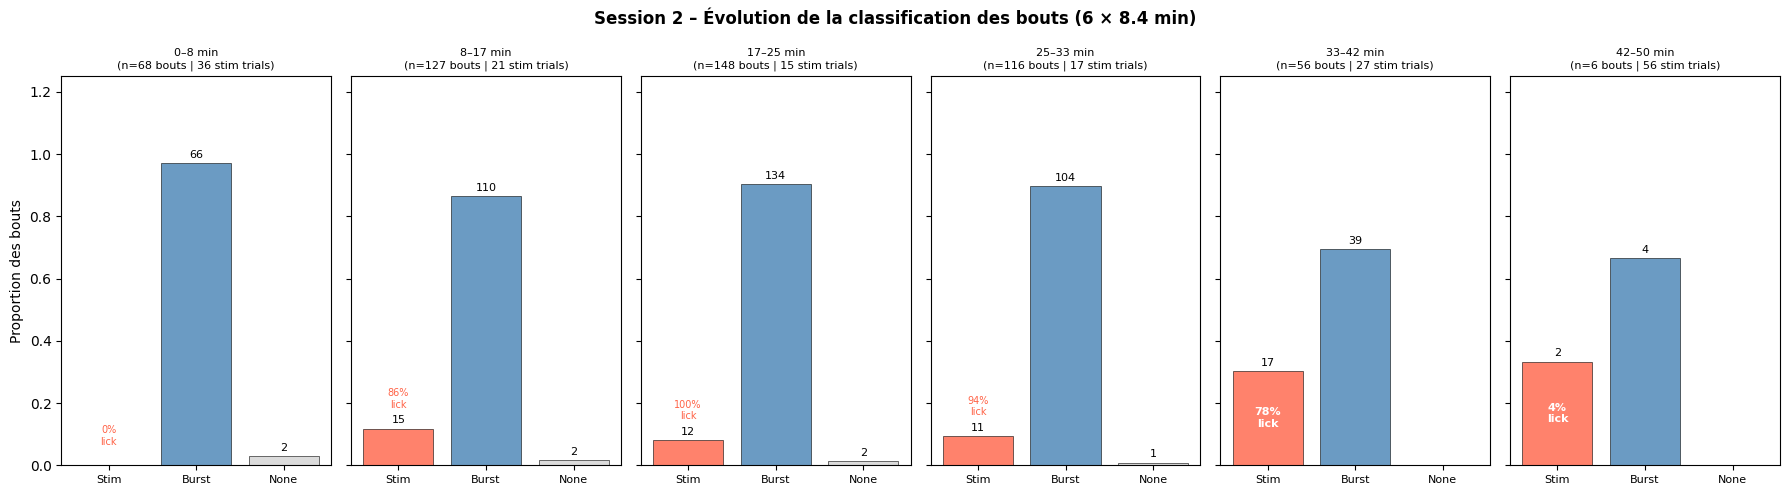

In [12]:
# ── Classification filtrée des bouts : évolution sur 6 fenêtres temporelles ───
N_SPLITS = 6
session_dur   = t_end2 - t_start2
window_size   = session_dur / N_SPLITS
split_edges   = [t_start2 + i * window_size for i in range(N_SPLITS + 1)]

colors_f2 = {'stim': 'tomato', 'burst': 'steelblue', 'none': 'lightgray'}
cats_f2   = ['stim', 'burst', 'none']

fig, axes = plt.subplots(1, N_SPLITS, figsize=(18, 5), sharey=True)
fig.suptitle(f'Session 2 – Évolution de la classification des bouts (6 × {window_size/60:.1f} min)',
             fontsize=12, fontweight='bold')

for k in range(N_SPLITS):
    t0_k = split_edges[k]
    t1_k = split_edges[k + 1]

    # Bouts dans cette fenêtre
    bout_mask = (bout_starts2 >= t0_k) & (bout_starts2 < t1_k)
    bout_idx  = np.where(bout_mask)[0]

    counts = {'stim': 0, 'burst': 0, 'none': 0}
    for i in bout_idx:
        t_b        = bout_starts2[i]
        candidates = det_t_best2[(det_t_best2 >= t_b - lick_window_s2) & (det_t_best2 < t_b)]
        if len(candidates) == 0:
            counts['none'] += 1
            continue
        has_stim = any(
            np.any((pk >= Stim_times2) & (pk <= Stim_times2 + tol_post2))
            for pk in candidates
        )
        counts['stim' if has_stim else 'burst'] += 1

    total = sum(counts.values())

    # % stim trials suivis d'un lick dans cette fenêtre
    stims_in_window = Stim_times2[(Stim_times2 >= t0_k) & (Stim_times2 < t1_k)]
    n_stim_lick = sum(
        np.any((all_lick_times_piezo2 >= st) & (all_lick_times_piezo2 <= st + lick_window_s2))
        for st in stims_in_window
    )
    pct_lick = (n_stim_lick / len(stims_in_window) * 100) if len(stims_in_window) > 0 else 0

    ax = axes[k]
    proportions = [counts[c] / total if total > 0 else 0 for c in cats_f2]
    bars = ax.bar(cats_f2, proportions,
                  color=[colors_f2[c] for c in cats_f2],
                  edgecolor='k', linewidth=0.5, alpha=0.8)

    # Count au-dessus de chaque barre
    for bar, c in zip(bars, cats_f2):
        n = counts[c]
        if n > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    str(n), ha='center', va='bottom', fontsize=8)

    # % lick : dans la barre si assez haute, sinon juste au-dessus
    stim_bar  = bars[cats_f2.index('stim')]
    stim_h    = stim_bar.get_height()
    stim_x    = stim_bar.get_x() + stim_bar.get_width() / 2
    if len(stims_in_window) > 0:
        if stim_h > 0.12:
            ax.text(stim_x, stim_h / 2, f'{pct_lick:.0f}%\nlick',
                    ha='center', va='center', fontsize=8, fontweight='bold', color='white')
        else:
            ax.text(stim_x, stim_h + 0.06, f'{pct_lick:.0f}%\nlick',
                    ha='center', va='bottom', fontsize=7, color='tomato')

    t0_min = (t0_k - t_start2) / 60
    t1_min = (t1_k - t_start2) / 60
    ax.set_title(f'{t0_min:.0f}–{t1_min:.0f} min\n(n={total} bouts | {len(stims_in_window)} stim trials)', fontsize=8)
    ax.set_ylim(0, 1.25)
    ax.set_xticklabels(['Stim', 'Burst', 'None'], fontsize=8)
    if k == 0:
        ax.set_ylabel('Proportion des bouts')

plt.tight_layout()
plt.show()